In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

conditions = [df['Glucose'] < 100, (df['Glucose'] >= 100) & (df['Glucose'] < 126), (df['Glucose'] >= 126) & (df['Glucose'] < 160) & (df['Outcome'] == 1), (df['Glucose'] >= 160) & (df['Outcome'] == 1)]
choices = ['Normal', 'Prediabetes', 'Moderate Diabetes', 'Severe Diabetes']
df['Severity'] = np.select(conditions, choices, default='Early Diabetes')

X = df.drop(['Outcome', 'Severity'], axis=1)
y = df['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("تم تجهيز البيانات وتدريب النموذج بنجاح")
print(f"دقة النموذج: {accuracy_score(y_test, y_pred):.2%}")

تم تجهيز البيانات وتدريب النموذج بنجاح
دقة النموذج: 88.96%


/tmp/ipykernel_3050/4154629139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Severity', order=df['Severity'].value_counts().index, palette='viridis')


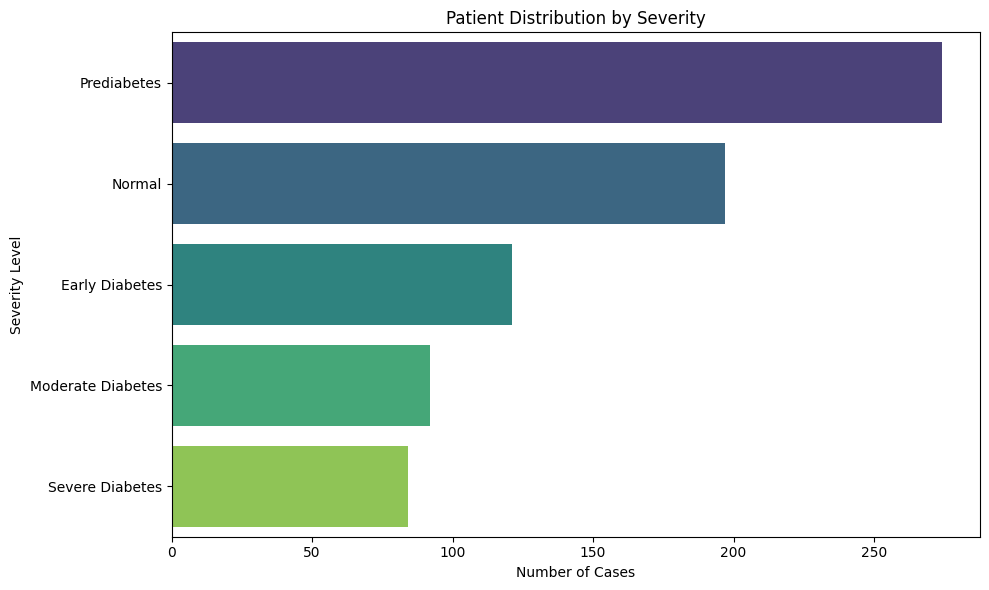

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Severity', order=df['Severity'].value_counts().index, palette='viridis')
plt.title('Patient Distribution by Severity')
plt.xlabel('Number of Cases')
plt.ylabel('Severity Level')
plt.tight_layout()
plt.show()

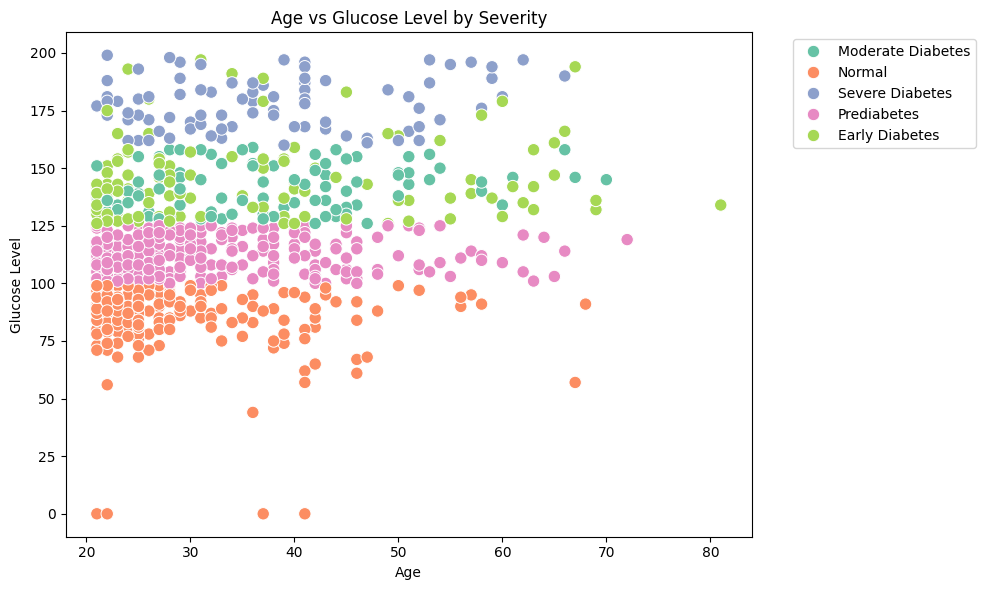

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Severity', palette='Set2', s=80)
plt.title('Age vs Glucose Level by Severity')
plt.xlabel('Age')
plt.ylabel('Glucose Level')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8896103896103896
                   precision    recall  f1-score   support

   Early Diabetes       0.65      0.62      0.64        24
Moderate Diabetes       0.64      0.78      0.70        18
           Normal       1.00      1.00      1.00        40
      Prediabetes       1.00      1.00      1.00        55
  Severe Diabetes       0.93      0.76      0.84        17

         accuracy                           0.89       154
        macro avg       0.84      0.83      0.84       154
     weighted avg       0.90      0.89      0.89       154



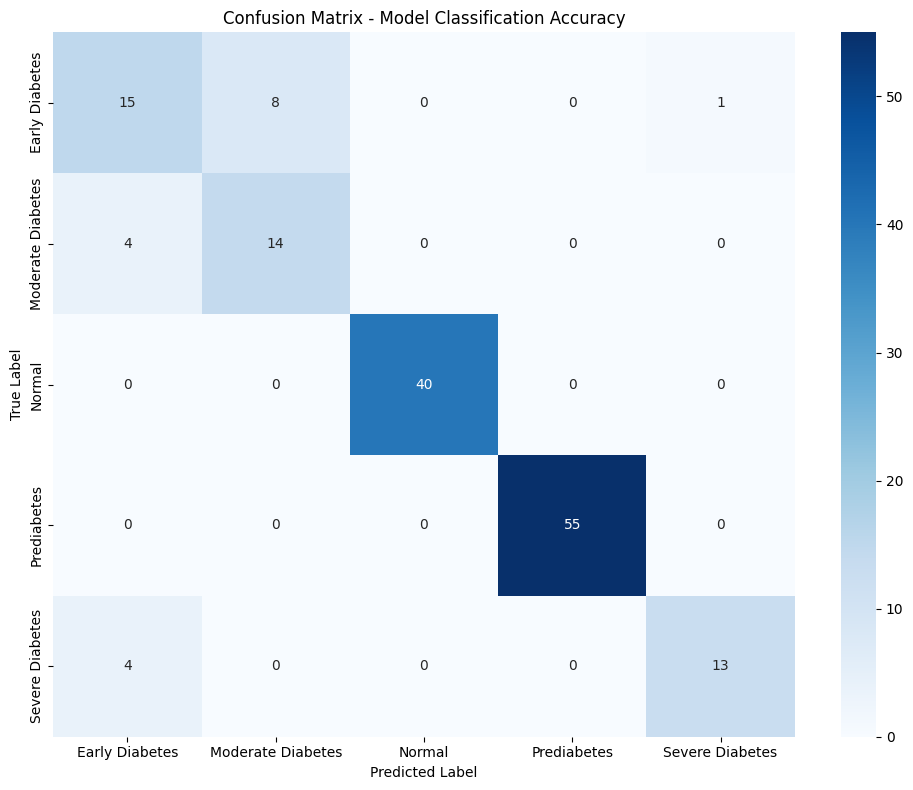

In [15]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Model Classification Accuracy')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3050/2990805612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


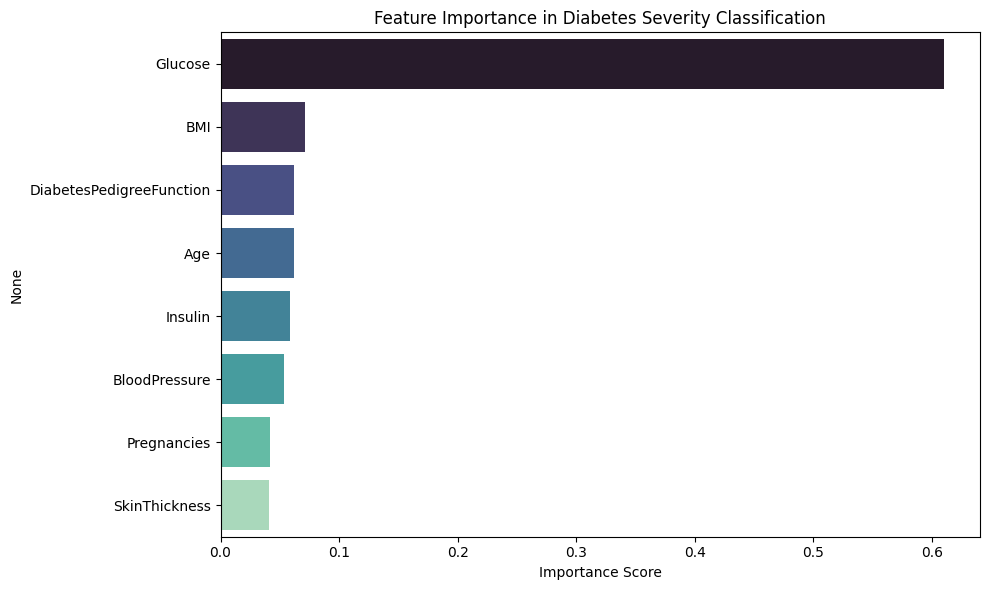

Glucose                     0.610026
BMI                         0.070956
DiabetesPedigreeFunction    0.061991
Age                         0.061773
Insulin                     0.058792
BloodPressure               0.053822
Pregnancies                 0.041581
SkinThickness               0.041059
dtype: float64


In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importance in Diabetes Severity Classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(importances)